# Session 4 — Activation Functions & Gradient Behavior

This notebook is an independently written practice version covering the same learning themes:
- Sigmoid
- Tanh
- ReLU
- Vanishing gradients
- Dying ReLU
- A scaled Sigmoid experiment

The examples use different values, organization, and visualizations so the focus is on understanding the concepts rather than reproducing a reference notebook.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Keep numerical output easy to read.
np.set_printoptions(precision=4, suppress=True)

print("NumPy version:", np.__version__)

NumPy version: 2.1.3


## 1. Sigmoid activation

The sigmoid maps any real-valued input into the interval `(0, 1)`.

In [2]:
def sigmoid(z):
    # Clipping prevents overflow for very large positive/negative values.
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

sample_points = np.array([-6.0, -2.5, -0.75, 0.0, 0.8, 2.5, 6.0])

for point in sample_points:
    print(f"x = {point:>5.2f}  ->  sigmoid(x) = {sigmoid(point):.4f}")

x = -6.00  ->  sigmoid(x) = 0.0025
x = -2.50  ->  sigmoid(x) = 0.0759
x = -0.75  ->  sigmoid(x) = 0.3208
x =  0.00  ->  sigmoid(x) = 0.5000
x =  0.80  ->  sigmoid(x) = 0.6900
x =  2.50  ->  sigmoid(x) = 0.9241
x =  6.00  ->  sigmoid(x) = 0.9975


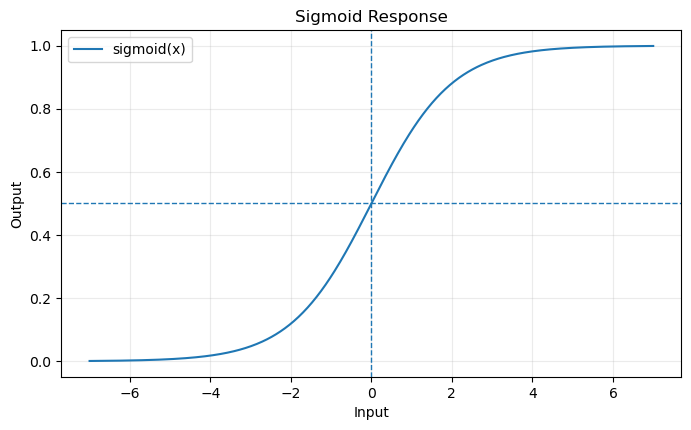

In [3]:
grid = np.linspace(-7, 7, 500)

plt.figure(figsize=(8, 4.5))
plt.plot(grid, sigmoid(grid), label="sigmoid(x)")
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Sigmoid Response")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Observation:** sigmoid is smooth and centered around zero, but its output saturates near 0 and 1. That saturation becomes important when discussing gradients.

## 2. Tanh activation

Tanh is also smooth, but unlike sigmoid its output is centered around zero.

In [4]:
def tanh_activation(z):
    return np.tanh(z)

test_values = np.array([-4.5, -1.75, -0.4, 0.0, 0.6, 1.8, 4.5])

for point in test_values:
    print(f"x = {point:>5.2f}  ->  tanh(x) = {tanh_activation(point):.4f}")

x = -4.50  ->  tanh(x) = -0.9998
x = -1.75  ->  tanh(x) = -0.9414
x = -0.40  ->  tanh(x) = -0.3799
x =  0.00  ->  tanh(x) = 0.0000
x =  0.60  ->  tanh(x) = 0.5370
x =  1.80  ->  tanh(x) = 0.9468
x =  4.50  ->  tanh(x) = 0.9998


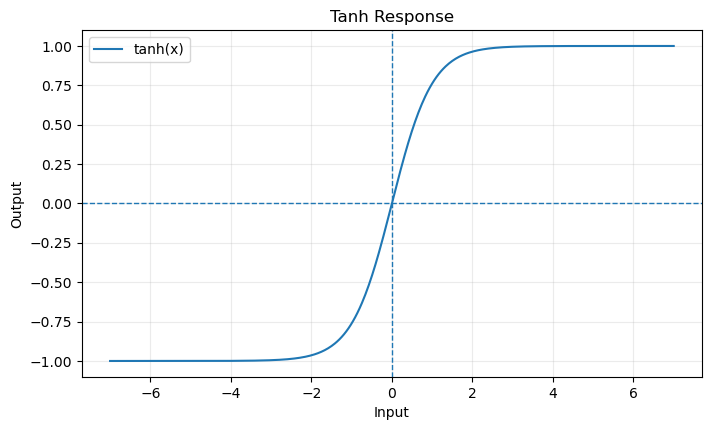

In [5]:
plt.figure(figsize=(8, 4.5))
plt.plot(grid, tanh_activation(grid), label="tanh(x)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Tanh Response")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Observation:** tanh produces negative values for negative inputs and positive values for positive inputs. Like sigmoid, it becomes nearly flat at extreme inputs.

## 3. ReLU activation

ReLU keeps positive values and replaces negative values with zero.

In [6]:
def relu(z):
    return np.maximum(0, z)

relu_inputs = np.array([-5.0, -1.2, -0.1, 0.0, 0.25, 1.5, 4.0])

print("Input      ReLU")
print("----------------")
for point in relu_inputs:
    print(f"{point:>6.2f}   {relu(point):>6.2f}")

Input      ReLU
----------------
 -5.00     0.00
 -1.20     0.00
 -0.10     0.00
  0.00     0.00
  0.25     0.25
  1.50     1.50
  4.00     4.00


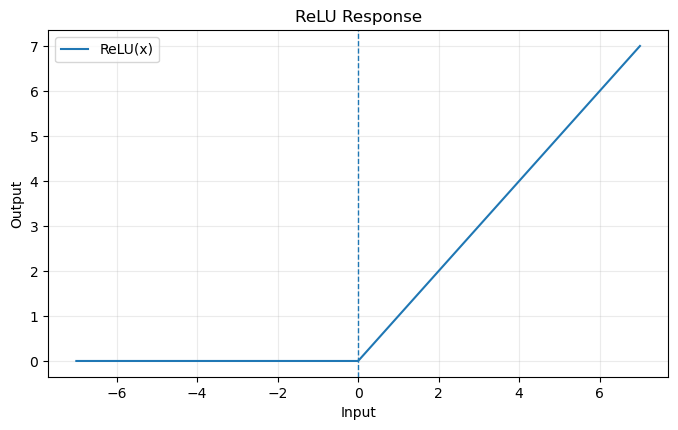

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(grid, relu(grid), label="ReLU(x)")
plt.axvline(0, linestyle="--", linewidth=1)
plt.title("ReLU Response")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Observation:** ReLU has a simple positive-side response and exactly zero output for negative inputs. This simplicity makes it useful in many neural networks, while also creating a possible dead-neuron problem.

## 4. Why gradients can vanish

For sigmoid and tanh, the derivative becomes small when the input is far from the center.

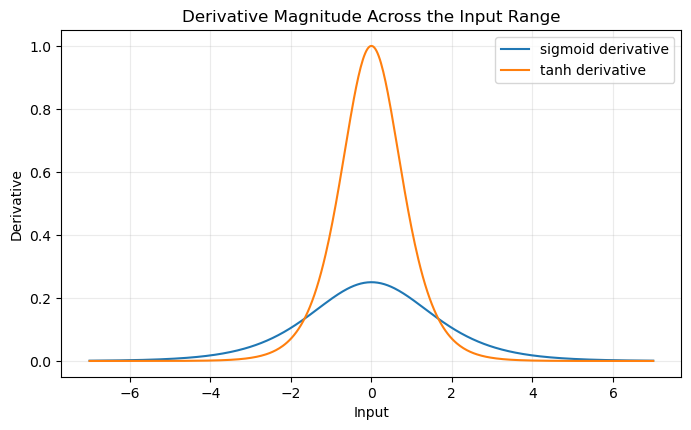

In [8]:
def sigmoid_derivative_from_output(s):
    return s * (1 - s)

def tanh_derivative_from_output(t):
    return 1 - t**2

sig_values = sigmoid(grid)
tanh_values = np.tanh(grid)

plt.figure(figsize=(8, 4.5))
plt.plot(grid, sigmoid_derivative_from_output(sig_values), label="sigmoid derivative")
plt.plot(grid, tanh_derivative_from_output(tanh_values), label="tanh derivative")
plt.title("Derivative Magnitude Across the Input Range")
plt.xlabel("Input")
plt.ylabel("Derivative")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Step  Gradient
   0  1.0000000000
   1  0.2500000000
   2  0.0625000000
   3  0.0156250000
   4  0.0039062500
   5  0.0009765625
   6  0.0002441406
   7  0.0000610352
   8  0.0000152588
   9  0.0000038147
  10  0.0000009537
  11  0.0000002384
  12  0.0000000596


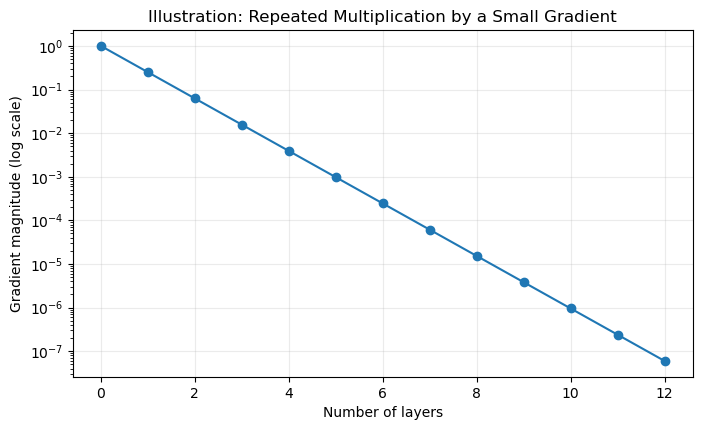

In [9]:
# A simple repeated-gradient illustration.
initial_gradient = 1.0
sigmoid_slope = 0.25

steps = np.arange(0, 13)
remaining = initial_gradient * (sigmoid_slope ** steps)

print("Step  Gradient")
for step, value in zip(steps, remaining):
    print(f"{step:>4}  {value:.10f}")

plt.figure(figsize=(8, 4.5))
plt.semilogy(steps, remaining, marker="o")
plt.title("Illustration: Repeated Multiplication by a Small Gradient")
plt.xlabel("Number of layers")
plt.ylabel("Gradient magnitude (log scale)")
plt.grid(alpha=0.25)
plt.show()

**Key idea:** during backpropagation, gradients are multiplied through many layers. If the relevant derivatives are consistently much smaller than 1, the resulting gradient can become extremely small. This is the **vanishing-gradient** effect.

## 5. Dying ReLU experiment

A ReLU unit can remain at zero when its pre-activation is negative.

In [10]:
def relu_derivative(z):
    return (z > 0).astype(float)

activation_inputs = np.array([-3.0, -1.0, -0.2, 0.2, 1.0, 3.0])

print("Input    ReLU output    derivative")
print("-----------------------------------")
for point in activation_inputs:
    print(f"{point:>5.1f}      {relu(point):>6.1f}         {relu_derivative(point):.1f}")

Input    ReLU output    derivative
-----------------------------------
 -3.0         0.0         0.0
 -1.0         0.0         0.0
 -0.2         0.0         0.0
  0.2         0.2         1.0
  1.0         1.0         1.0
  3.0         3.0         1.0


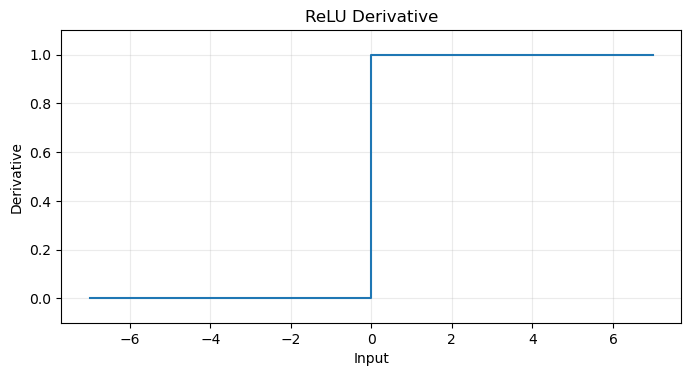

In [11]:
# Visualize the derivative as a step-like function.
relu_grad = relu_derivative(grid)

plt.figure(figsize=(8, 3.8))
plt.step(grid, relu_grad, where="mid")
plt.title("ReLU Derivative")
plt.xlabel("Input")
plt.ylabel("Derivative")
plt.ylim(-0.1, 1.1)
plt.grid(alpha=0.25)
plt.show()

**Observation:** for negative pre-activation values, the ReLU derivative is zero. If a unit repeatedly receives values in this region, its parameters may stop receiving useful gradient updates. This is commonly called the **dying ReLU** problem.

## 6. Scaled sigmoid comparison

Changing the scale of the sigmoid input changes how quickly the activation moves between its saturated regions.

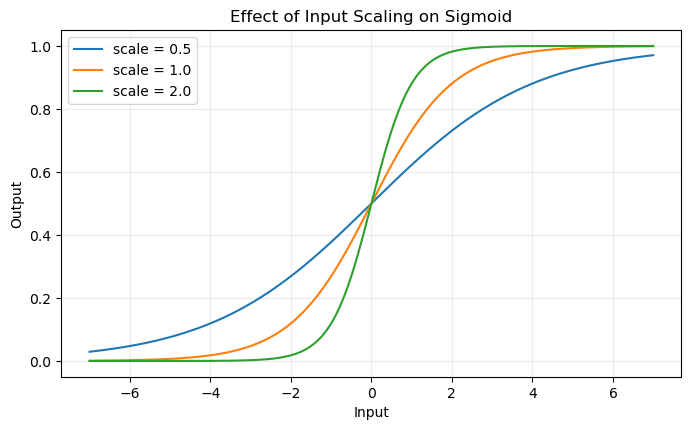

In [12]:
def scaled_sigmoid(z, scale=1.0):
    return sigmoid(scale * z)

scales = [0.5, 1.0, 2.0]

plt.figure(figsize=(8, 4.5))
for factor in scales:
    plt.plot(grid, scaled_sigmoid(grid, factor), label=f"scale = {factor}")

plt.title("Effect of Input Scaling on Sigmoid")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### Final takeaways

1. **Sigmoid** gives outputs between 0 and 1 but can saturate at extreme inputs.
2. **Tanh** is zero-centered and ranges from -1 to 1, but it can also saturate.
3. **ReLU** is computationally simple and preserves positive signals.
4. **Vanishing gradients** can occur when many small derivatives are multiplied during backpropagation.
5. **Dying ReLU** occurs when a ReLU unit stays on its zero-gradient side.
6. Changing the input scale changes the shape of the effective sigmoid response.

Try changing the sample values and scale factors yourself and observe how the graphs change.